In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [421]:
df_p = pd.read_csv('../data/raw/pollution.csv')
df_m = pd.read_csv('../data/raw/meteo.csv')

df_p['time'] = pd.to_datetime(df_p['time']).dt.tz_localize("Asia/Krasnoyarsk")
df_m['time'] = pd.to_datetime(df_m['time']).dt.tz_convert("Asia/Krasnoyarsk")

In [422]:
df_p

,time,site,t,p,h,aqi,iaqi,pm25,pm10,pm25_mcp
0,2022-01-01 00:00:00+07:00,3837,-13.9,747.7,64.0,11.0,24.0,5.9,6.3,0.08
1,2022-01-01 00:00:00+07:00,3841,-12.9,754.9,65.0,56.0,65.0,18.9,21.9,0.42
2,2022-01-01 00:00:00+07:00,3842,-13.2,757.8,68.0,62.0,55.0,14.4,17.2,0.50
3,2022-01-01 00:00:00+07:00,3843,-12.9,757.4,66.0,14.0,35.0,8.5,10.5,0.09
4,2022-01-01 00:00:00+07:00,3847,-13.9,752.2,86.0,70.0,69.0,20.9,25.6,0.61
...,...,...,...,...,...,...,...,...,...,...
749116,2025-12-31 23:00:00+07:00,4227,-1.1,752.8,67.0,105.0,13.0,3.1,4.0,1.06
749117,2025-12-31 23:00:00+07:00,4228,-42.5,715.3,38.0,108.0,5.0,1.2,1.4,1.10
749118,2025-12-31 23:00:00+07:00,4324,-1.0,751.8,65.0,9.0,17.0,4.1,5.4,0.06
749119,2025-12-31 23:00:00+07:00,4325,19.8,562.5,82.0,113.0,43.0,10.4,14.7,1.15


In [423]:
df_m

,time,temperature_2m,relative_humidity_2m,pressure_msl,surface_pressure,temperature_80m,temperature_120m,temperature_180m,wind_speed_10m,wind_speed_80m,wind_speed_120m,wind_speed_180m,wind_direction_10m,wind_direction_80m,wind_direction_120m,wind_direction_180m,precipitation,shortwave_radiation
0,2021-12-31 07:00:00+07:00,-19.10,69.995420,1038.4,1013.62384,-17.685,-17.885,NaN,3.420526,7.274277,7.617616,NaN,254.74483,252.05050,252.05050,NaN,0.0,0.0
1,2021-12-31 08:00:00+07:00,-18.55,69.810265,1038.5,1013.77405,-17.635,-17.835,NaN,3.361547,7.026492,7.358136,NaN,247.24900,246.27959,246.27959,NaN,0.0,0.0
2,2021-12-31 09:00:00+07:00,-18.30,70.484085,1038.5,1013.79803,-17.435,-17.585,NaN,3.275668,6.987853,7.317673,NaN,238.73633,239.85869,239.85869,NaN,0.0,0.0
3,2021-12-31 10:00:00+07:00,-17.80,70.594500,1038.4,1013.74800,-17.135,-17.285,NaN,3.689173,7.299048,7.643556,NaN,237.17146,235.88548,235.88548,NaN,0.0,7.0
4,2021-12-31 11:00:00+07:00,-16.90,68.669130,1037.9,1013.34520,-16.685,-16.835,NaN,4.161730,7.682065,8.044651,NaN,234.78232,234.29321,234.29321,NaN,0.0,53.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35107,2026-01-02 02:00:00+07:00,-1.85,82.094246,1029.1,1006.08594,-1.708,-2.208,-2.708,3.996561,7.548740,7.905034,10.139461,223.47928,226.30782,226.30782,234.52720,0.1,0.0
35108,2026-01-02 03:00:00+07:00,-2.05,84.258730,1029.7,1006.65570,-1.708,-2.208,-2.908,3.162673,6.306303,6.603954,8.324730,219.22566,224.68694,224.68694,236.87625,0.1,0.0
35109,2026-01-02 04:00:00+07:00,-2.20,85.839420,1030.0,1006.93634,-1.708,-2.308,-3.008,2.842974,5.763197,6.035214,7.409162,214.24908,221.91510,221.91510,234.50668,0.0,0.0
35110,2026-01-02 05:00:00+07:00,-2.35,89.774820,1030.7,1007.60800,-1.908,-2.508,-3.208,3.185122,6.340107,6.639354,8.466695,227.54485,235.33263,235.33263,247.32861,0.1,0.0


In [457]:
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 749121 entries, 0 to 749120
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype                           
---  ------    --------------   -----                           
 0   time      749121 non-null  datetime64[ns, Asia/Krasnoyarsk]
 1   site      749121 non-null  int64                           
 2   t         693651 non-null  float64                         
 3   p         629385 non-null  float64                         
 4   h         693961 non-null  float64                         
 5   aqi       748829 non-null  float64                         
 6   iaqi      746936 non-null  float64                         
 7   pm25      746936 non-null  float64                         
 8   pm10      746936 non-null  float64                         
 9   pm25_mcp  748829 non-null  float64                         
dtypes: datetime64[ns, Asia/Krasnoyarsk](1), float64(8), int64(1)
memory usage: 57.2 MB


In [459]:
df_m.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35112 entries, 0 to 35111
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype                           
---  ------                --------------  -----                           
 0   time                  35112 non-null  datetime64[ns, Asia/Krasnoyarsk]
 1   temperature_2m        35112 non-null  float64                         
 2   relative_humidity_2m  35112 non-null  float64                         
 3   pressure_msl          35112 non-null  float64                         
 4   surface_pressure      35112 non-null  float64                         
 5   temperature_80m       35112 non-null  float64                         
 6   temperature_120m      35112 non-null  float64                         
 7   temperature_180m      27424 non-null  float64                         
 8   wind_speed_10m        35112 non-null  float64                         
 9   wind_speed_80m        35112 non-null  float64     

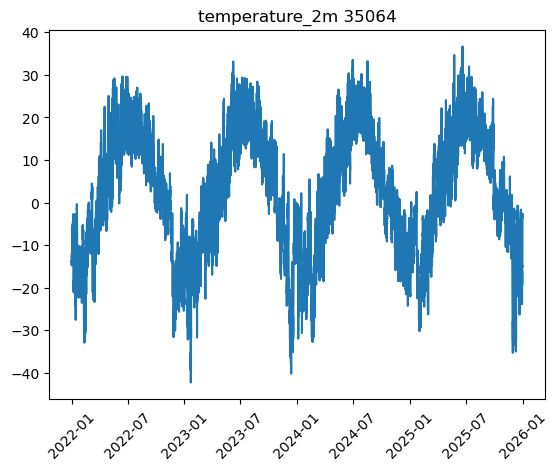

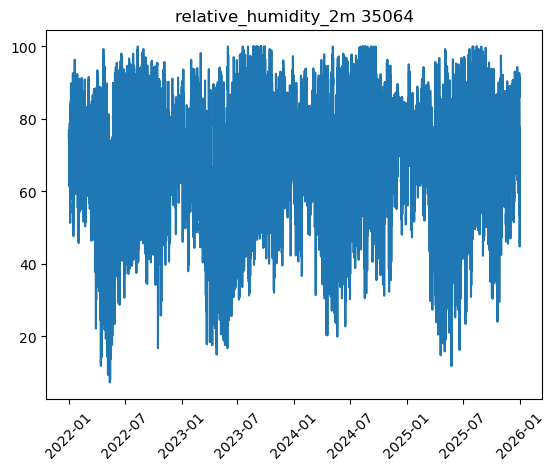

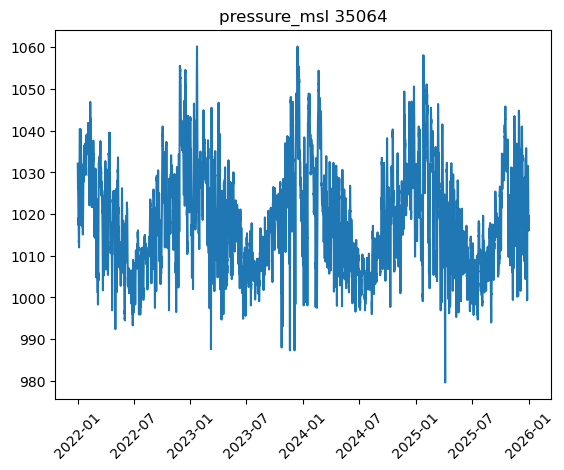

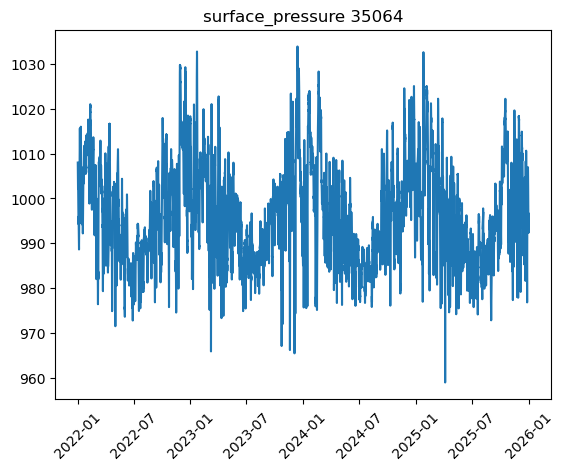

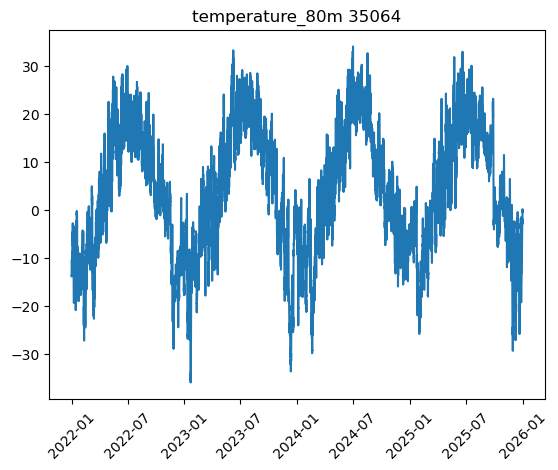

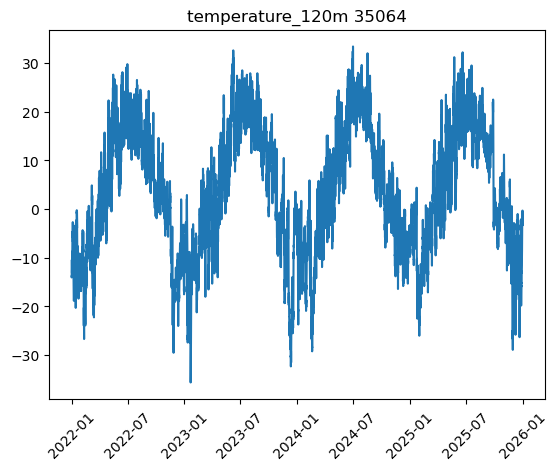

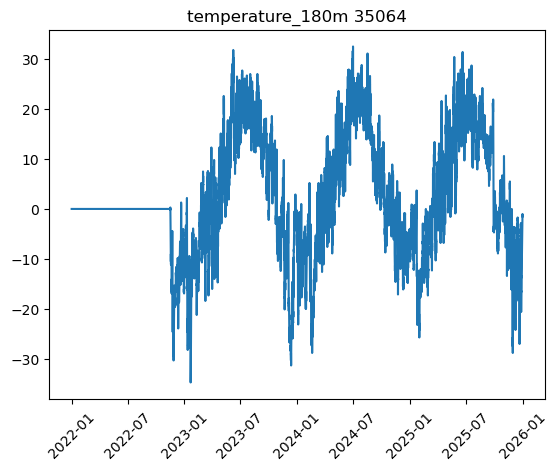

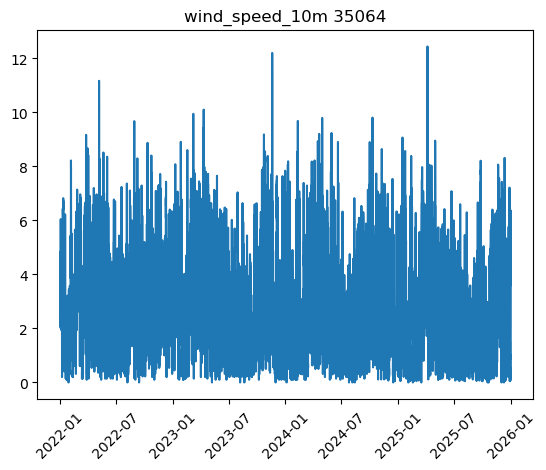

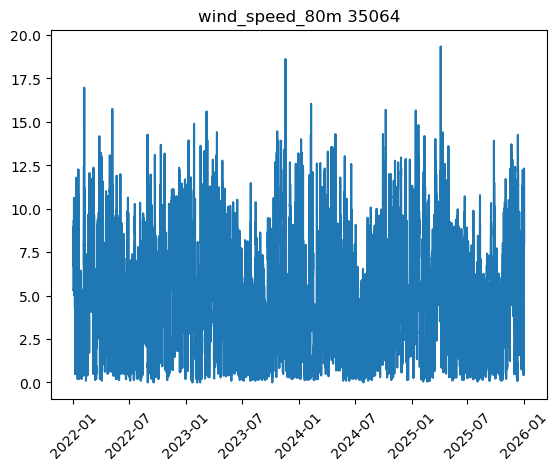

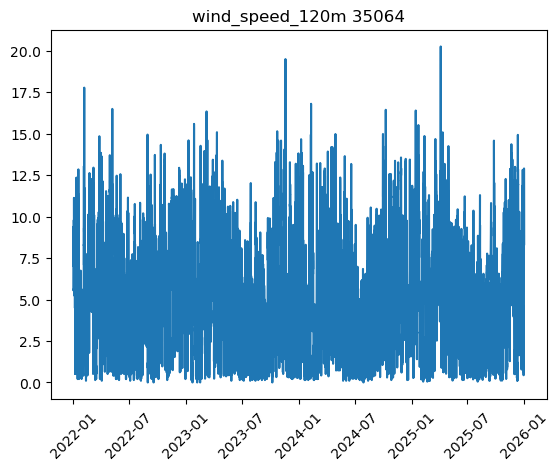

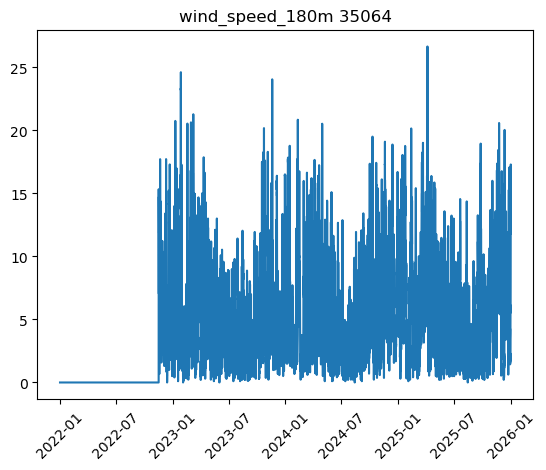

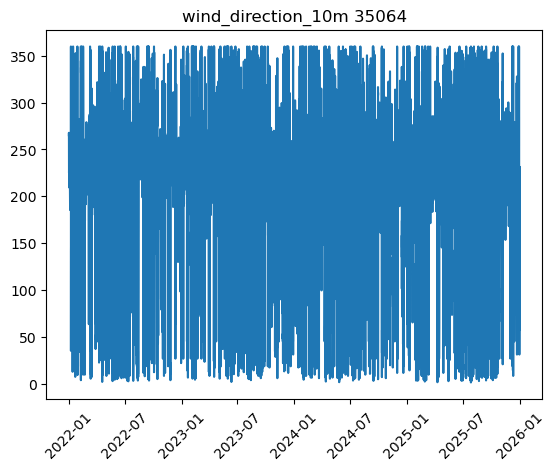

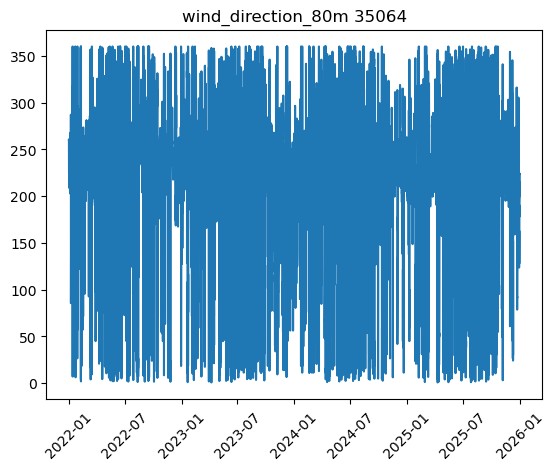

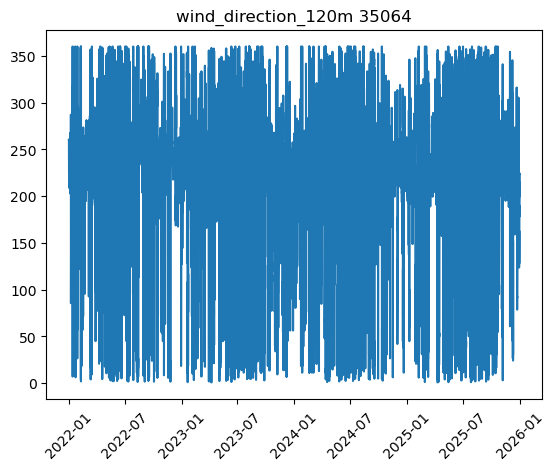

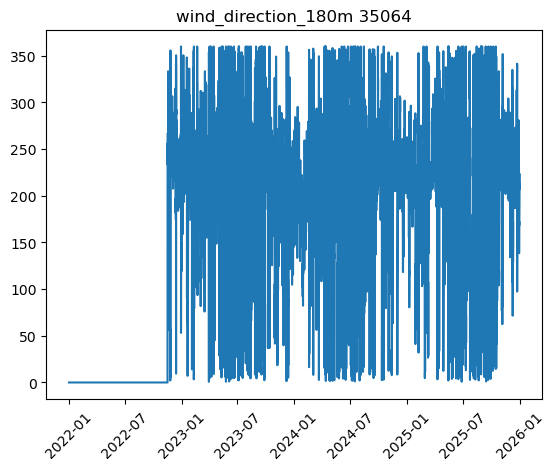

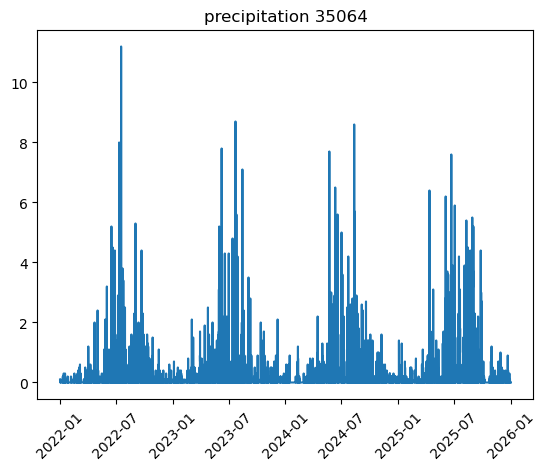

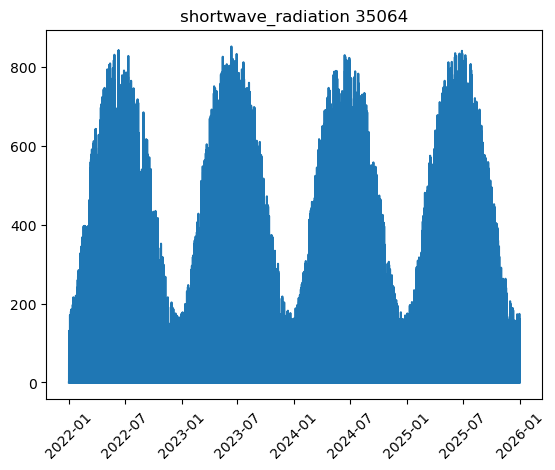

In [393]:
hour_range = pd.DataFrame({'time':pd.date_range(df_p['time'].min(),df_p['time'].max(),freq='1h')})

for col in df_m.columns[1:]:
    column = df_m[['time',col]].copy()
    column = column.sort_values('time')
    sub = pd.merge(column, hour_range, on='time', how='right')

    nan_idxs = sub[col].isnull()
    sub.loc[nan_idxs, col] = 0
    
    plt.plot(sub['time'], sub[col].values)
    plt.title(f"{col} {sub.shape[0]}")
    plt.xticks(rotation=45)
    plt.show()

In [395]:
df_m.isnull().sum(axis=0)

time                       0
temperature_2m             0
relative_humidity_2m       0
pressure_msl               0
surface_pressure           0
temperature_80m            0
temperature_120m           0
temperature_180m        7688
wind_speed_10m             0
wind_speed_80m             0
wind_speed_120m            0
wind_speed_180m         7688
wind_direction_10m         0
wind_direction_80m         0
wind_direction_120m        0
wind_direction_180m     7688
precipitation              0
shortwave_radiation        0
dtype: int64

In [397]:
df_m[df_m['time'] >= "2023-01-01"].isnull().sum(axis=0)

time                    0
temperature_2m          0
relative_humidity_2m    0
pressure_msl            0
surface_pressure        0
temperature_80m         0
temperature_120m        0
temperature_180m        0
wind_speed_10m          0
wind_speed_80m          0
wind_speed_120m         0
wind_speed_180m         0
wind_direction_10m      0
wind_direction_80m      0
wind_direction_120m     0
wind_direction_180m     0
precipitation           0
shortwave_radiation     0
dtype: int64

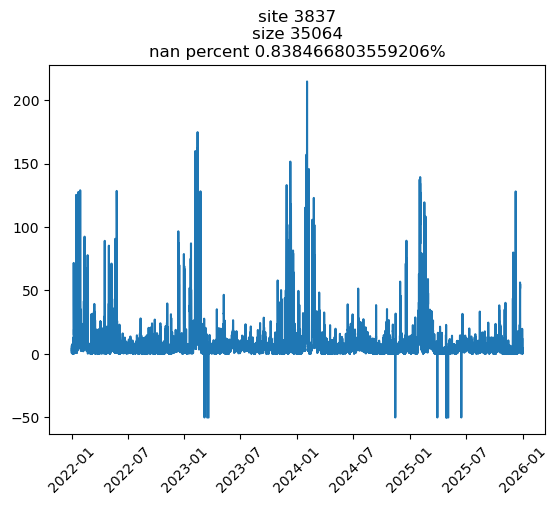

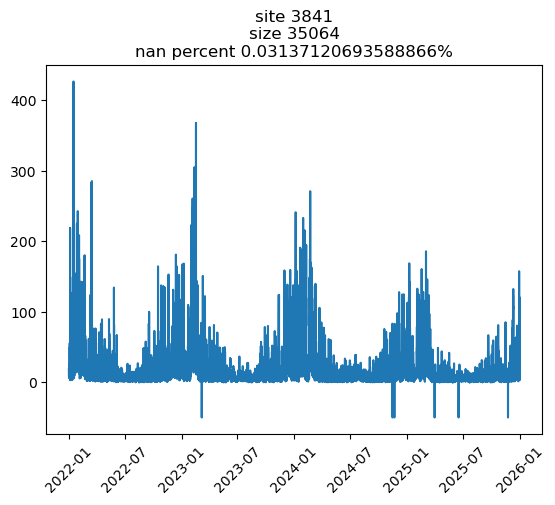

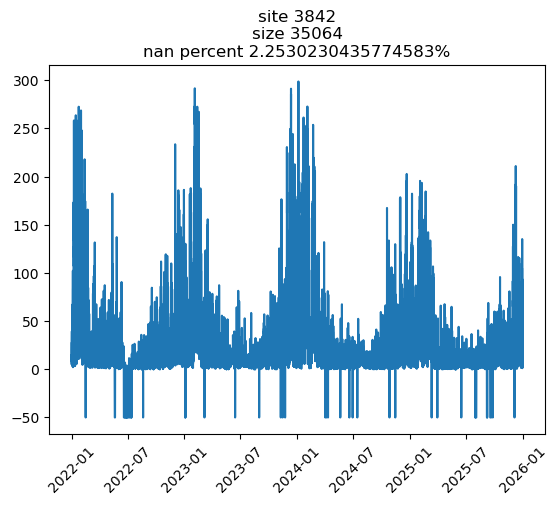

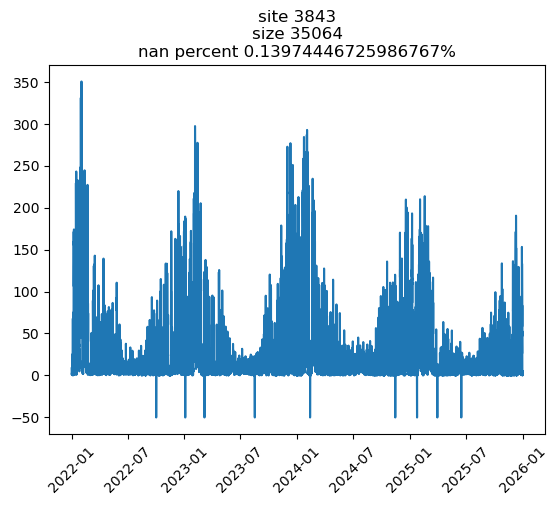

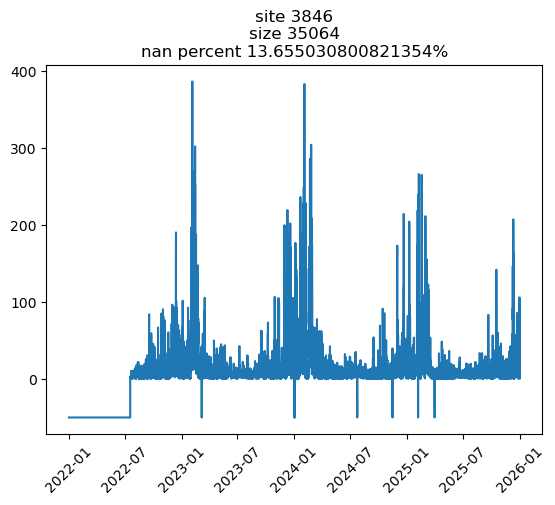

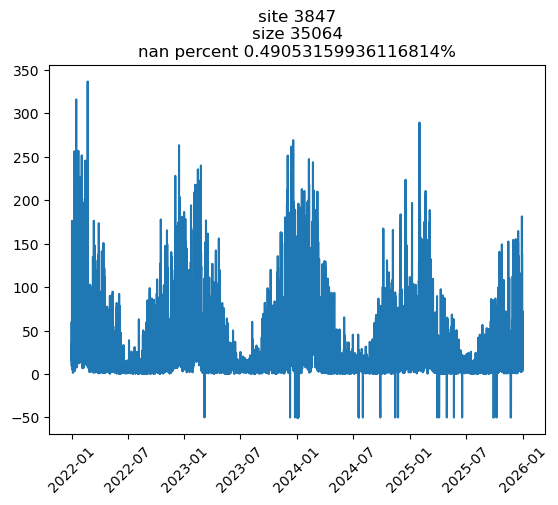

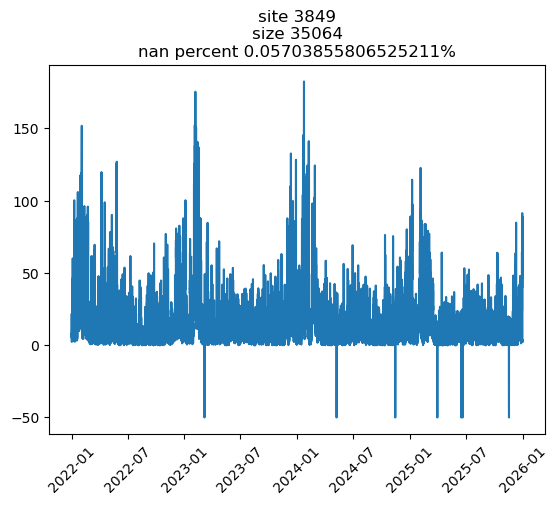

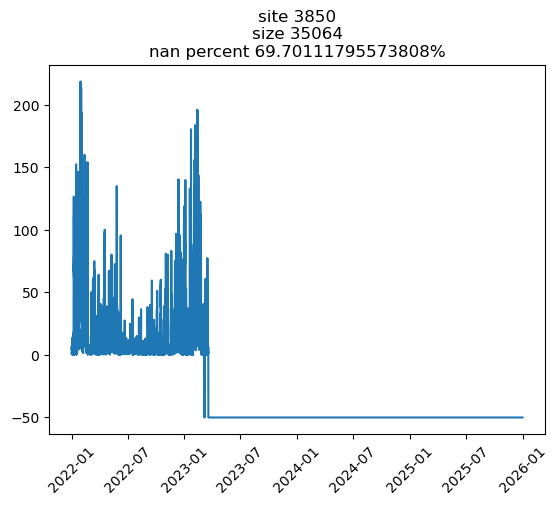

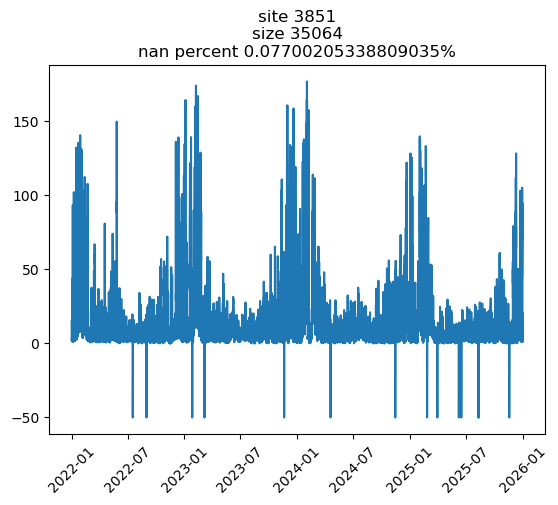

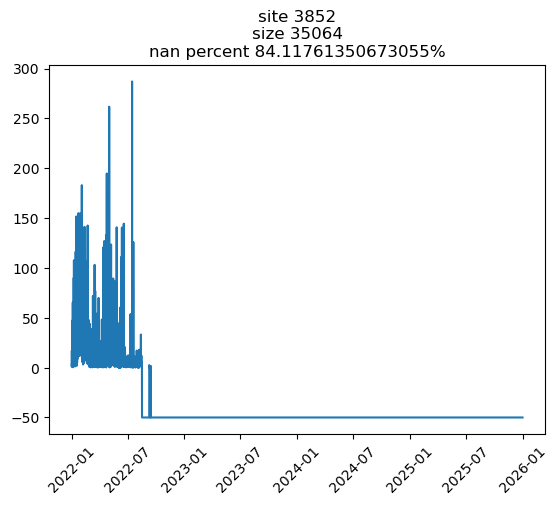

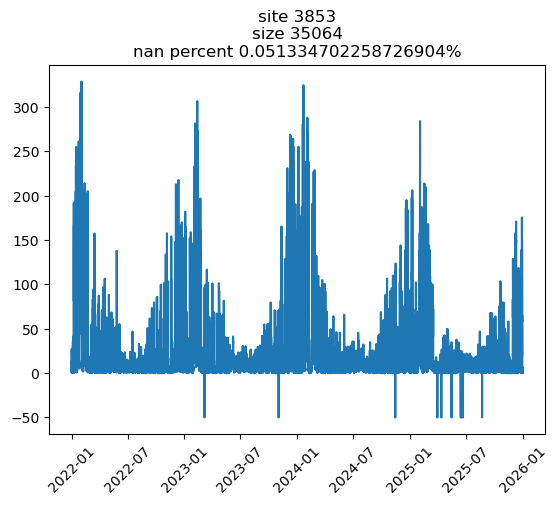

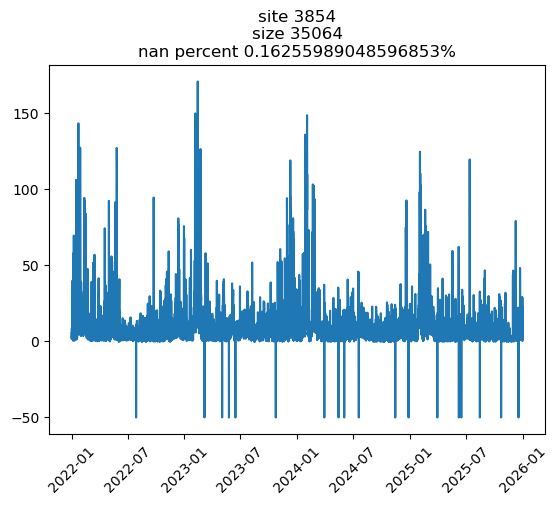

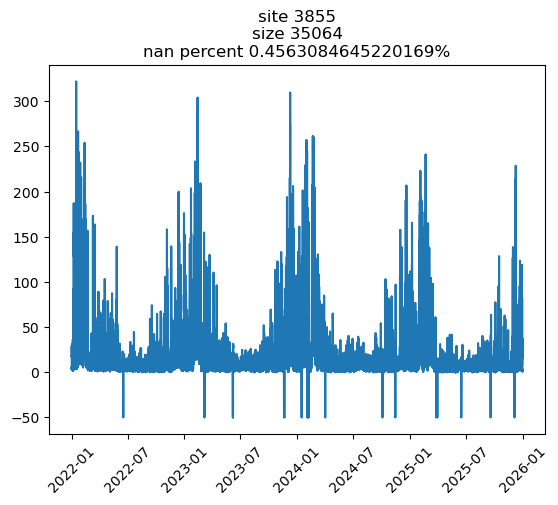

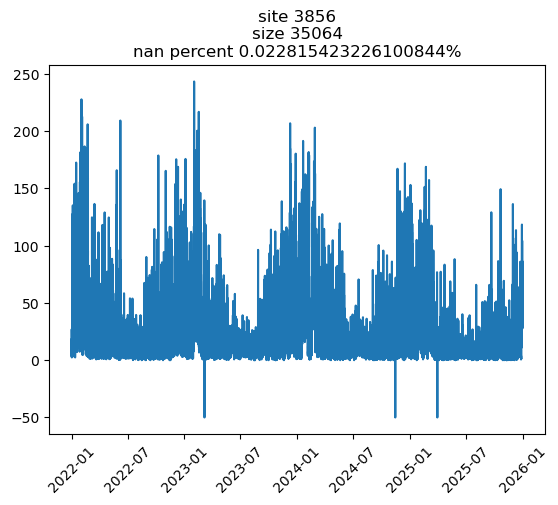

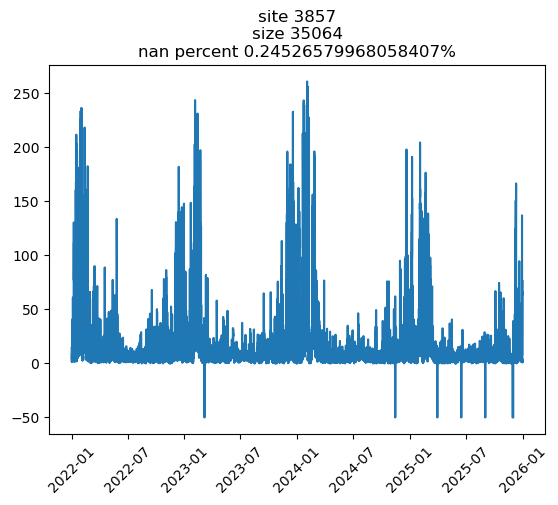

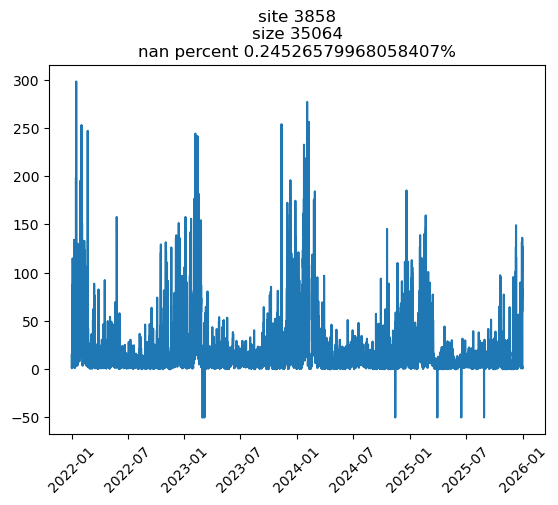

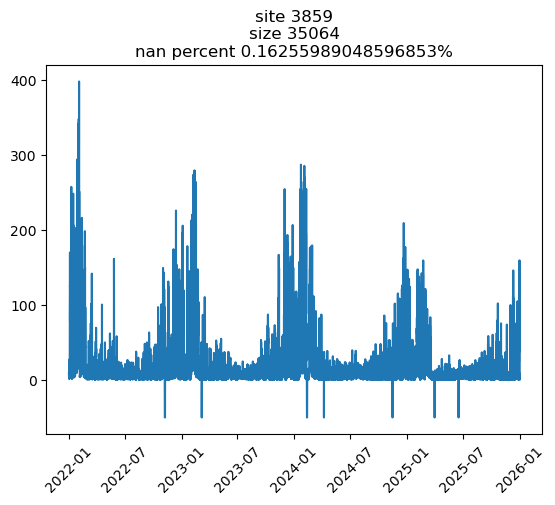

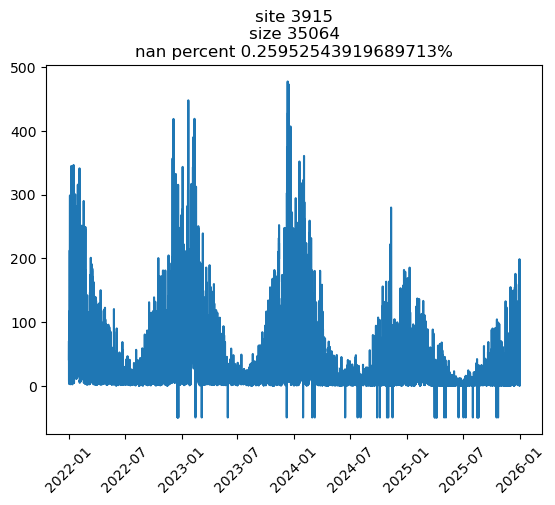

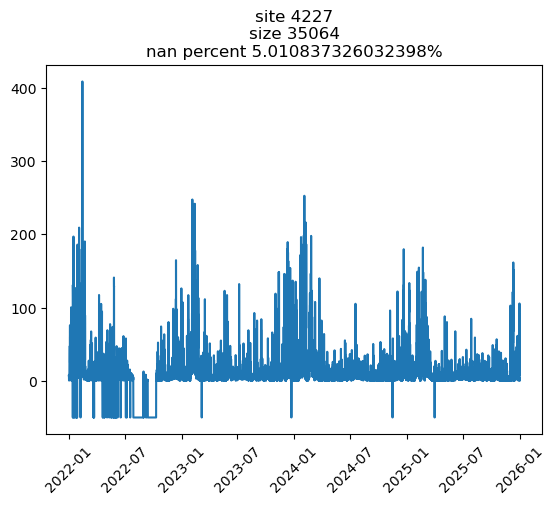

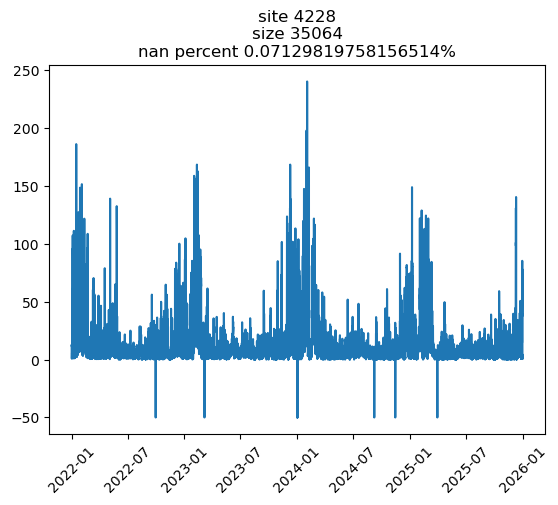

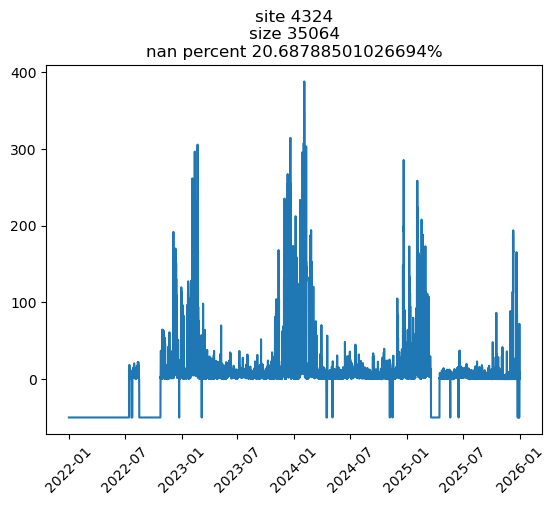

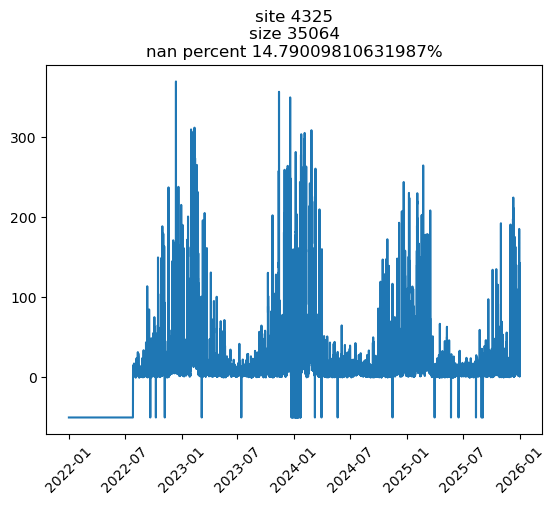

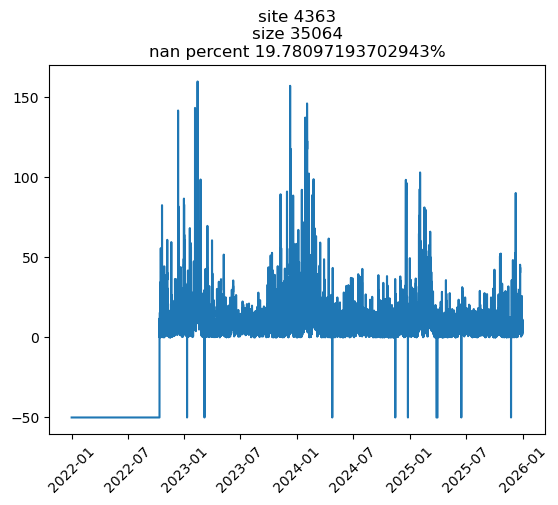

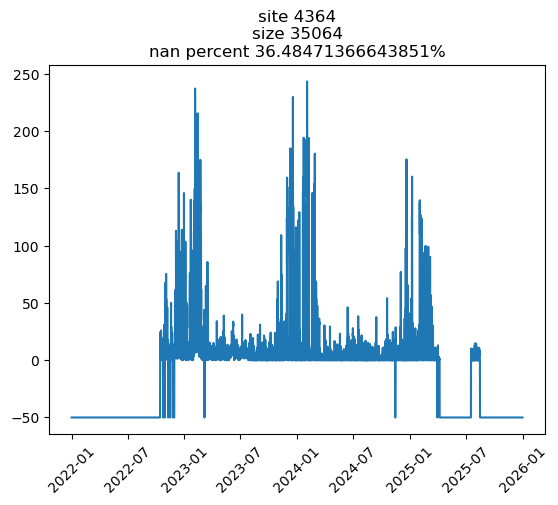

In [399]:
hour_range = pd.DataFrame({'time':pd.date_range(df_p['time'].min(),df_p['time'].max(),freq='1h')})
hour_range['time'] = pd.to_datetime(hour_range['time'], utc=True)

for site, group in df_p.groupby('site'):
    group = group.sort_values('time')
    group['time'] = pd.to_datetime(group['time'])
    sub = pd.merge(group, hour_range, on='time', how='right')

    nan_idxs = sub['pm25'].isnull()
    sub.loc[nan_idxs, 'pm25'] = -50
    
    plt.plot(sub['time'], sub['pm25'].values)
    plt.title(f"site {site}\nsize {sub.shape[0]}\nnan percent {(sub[nan_idxs].shape[0]/sub.shape[0])*100}%")
    plt.xticks(rotation=45)
    plt.show()

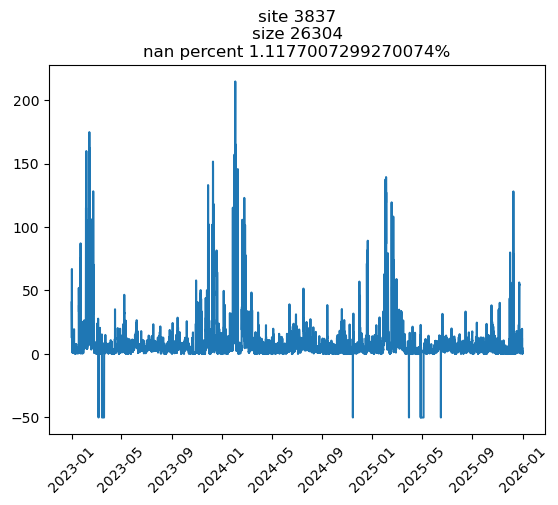

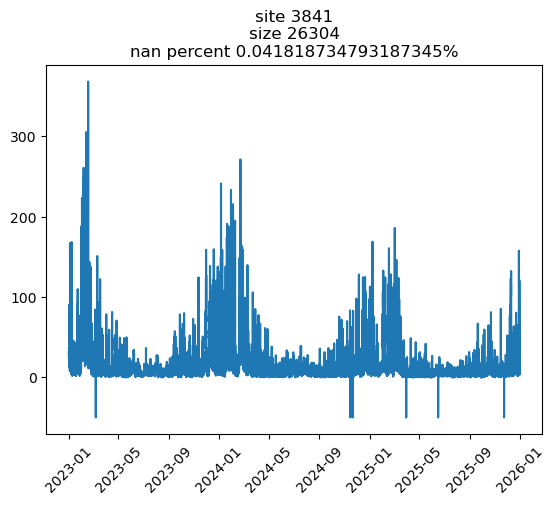

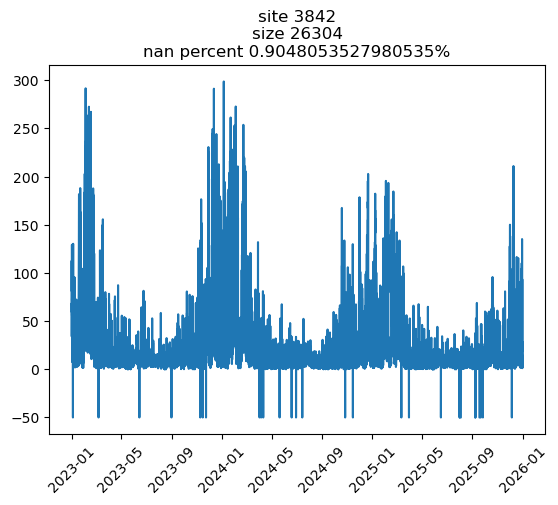

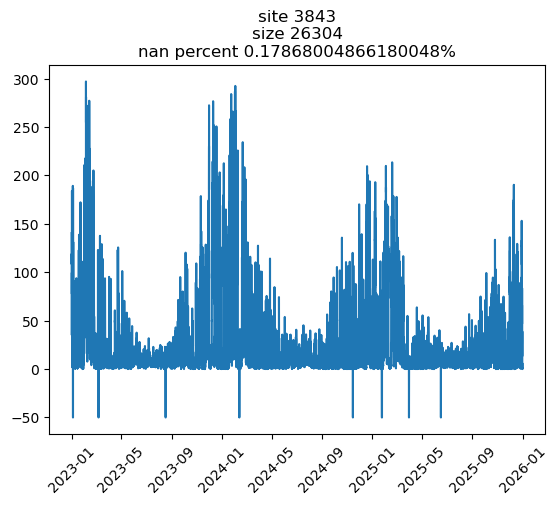

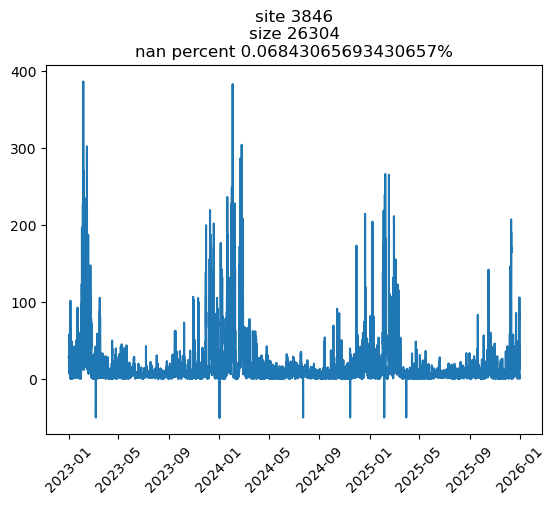

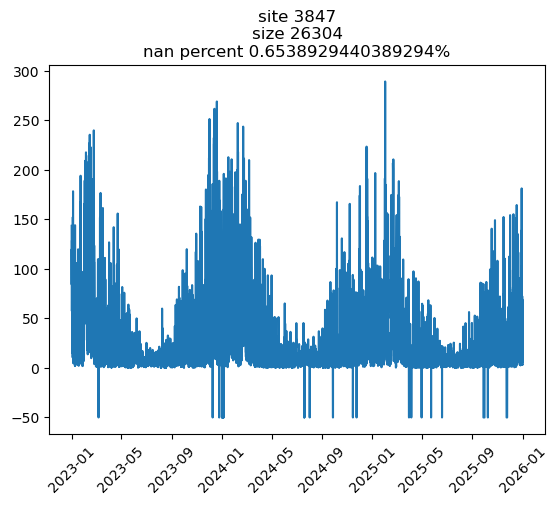

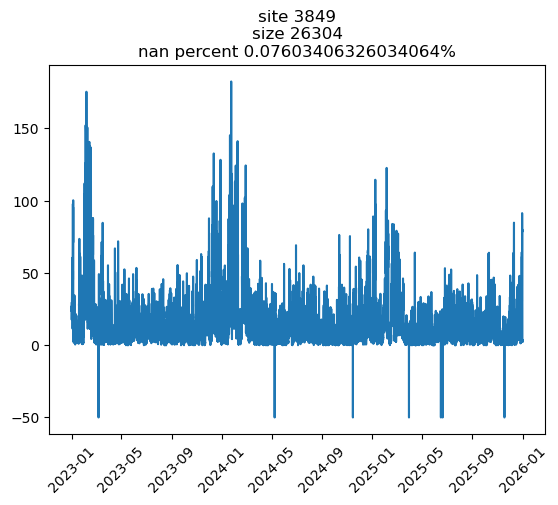

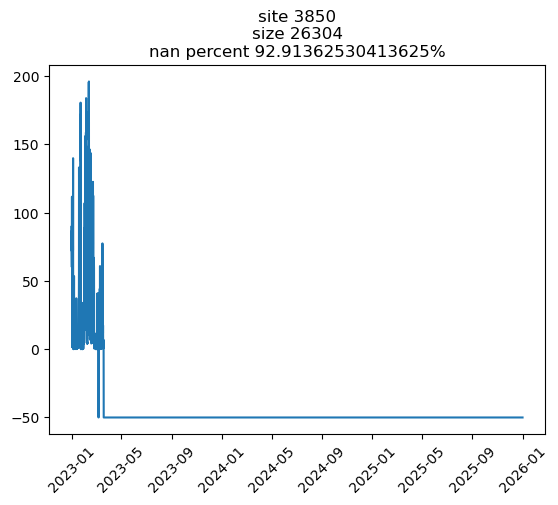

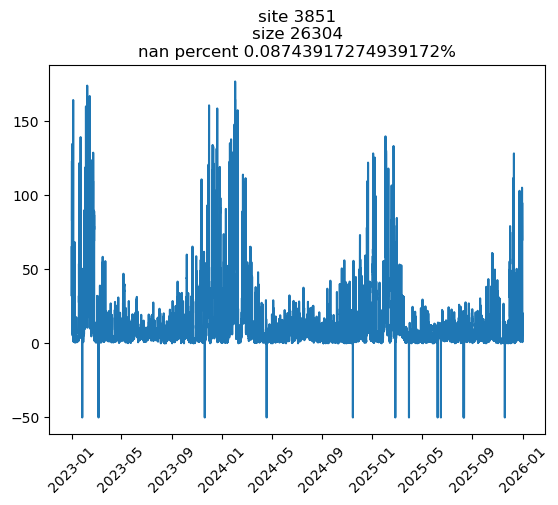

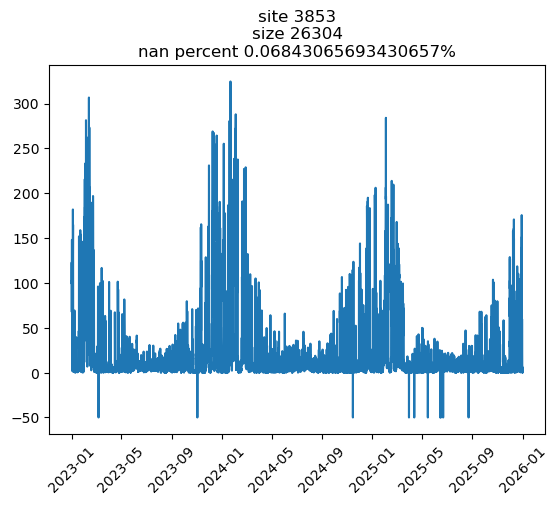

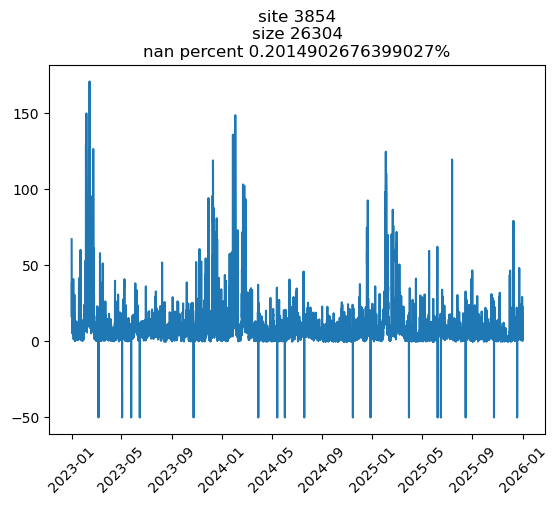

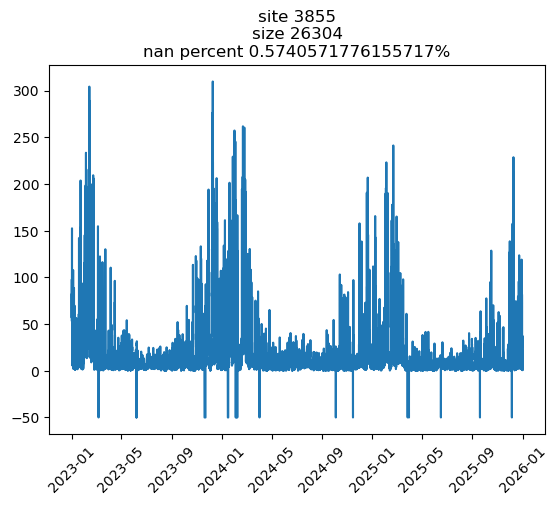

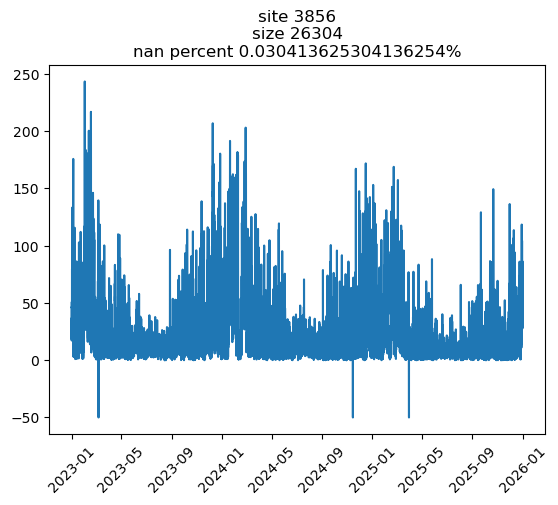

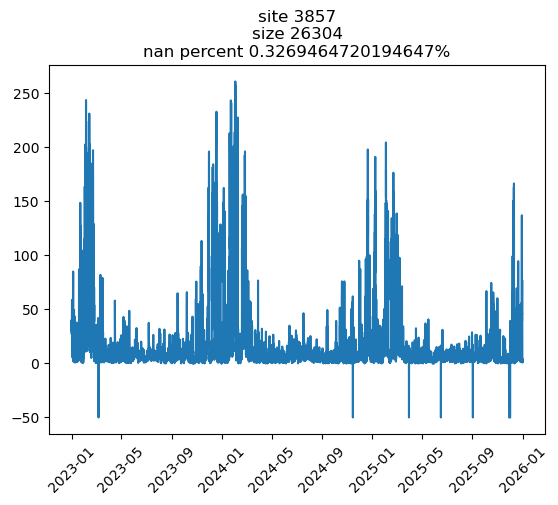

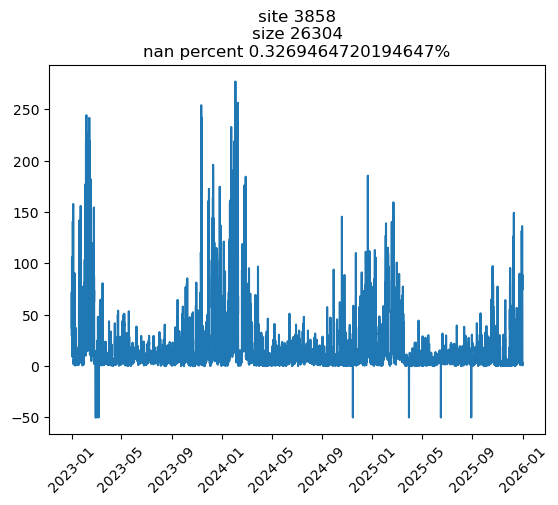

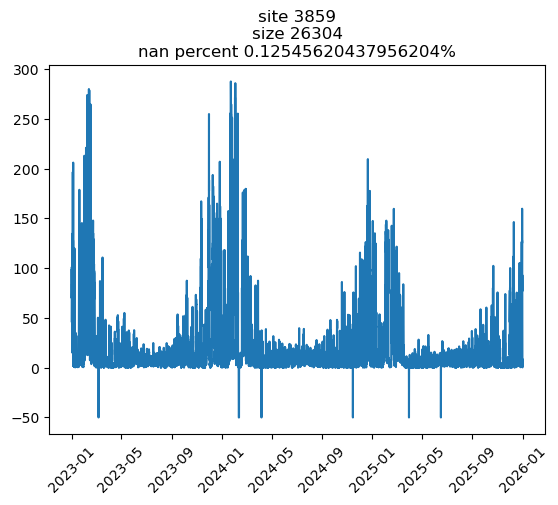

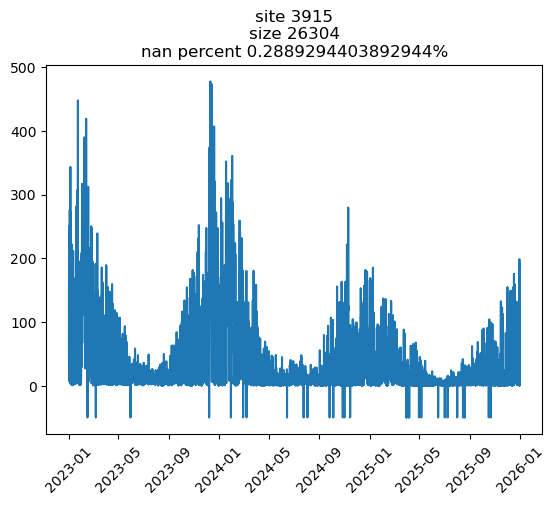

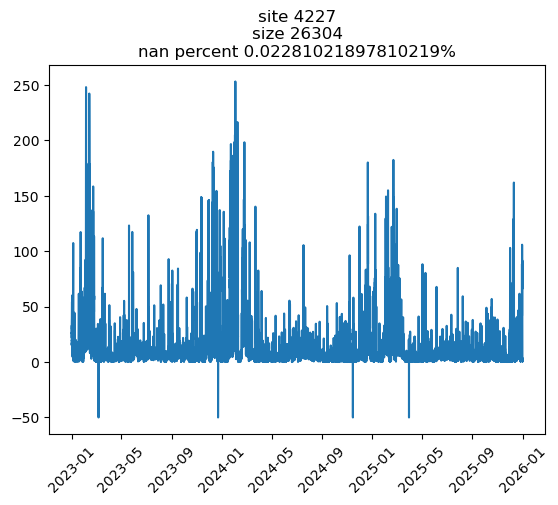

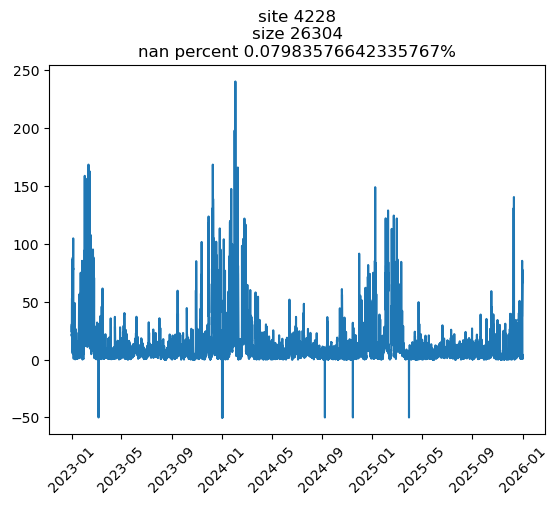

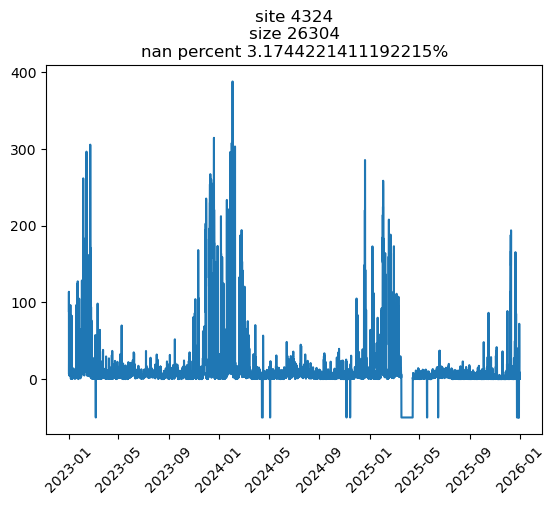

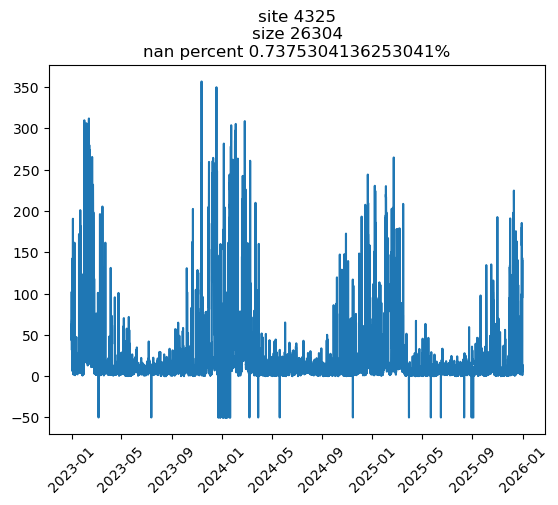

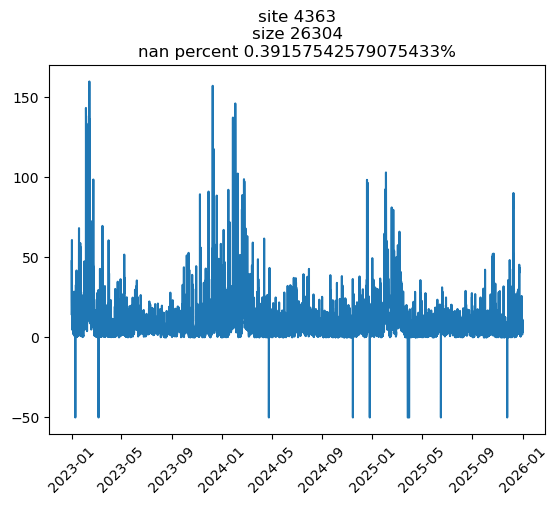

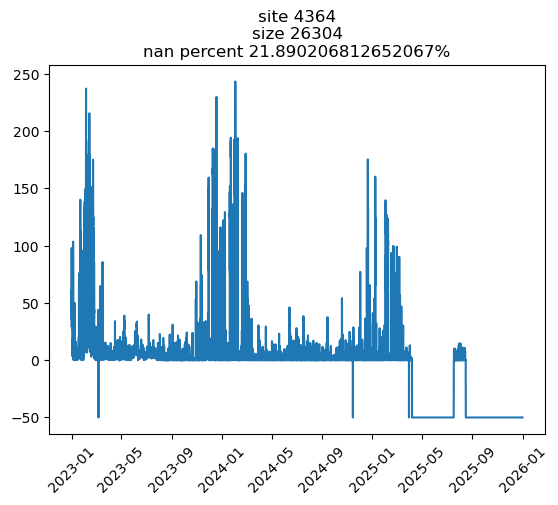

In [401]:
hour_range = pd.DataFrame({'time':pd.date_range(df_p_filt['time'].min(),df_p_filt['time'].max(),freq='1h')})
hour_range['time'] = pd.to_datetime(hour_range['time'], utc=True)

for site, group in df_p_filt.groupby('site'):
    group = group.sort_values('time')
    group['time'] = pd.to_datetime(group['time'])
    sub = pd.merge(group, hour_range, on='time', how='right')

    nan_idxs = sub['pm25'].isnull()
    sub.loc[nan_idxs, 'pm25'] = -50
    
    plt.plot(sub['time'], sub['pm25'].values)
    plt.title(f"site {site}\nsize {sub.shape[0]}\nnan percent {(sub[nan_idxs].shape[0]/sub.shape[0])*100}%")
    plt.xticks(rotation=45)
    plt.show()

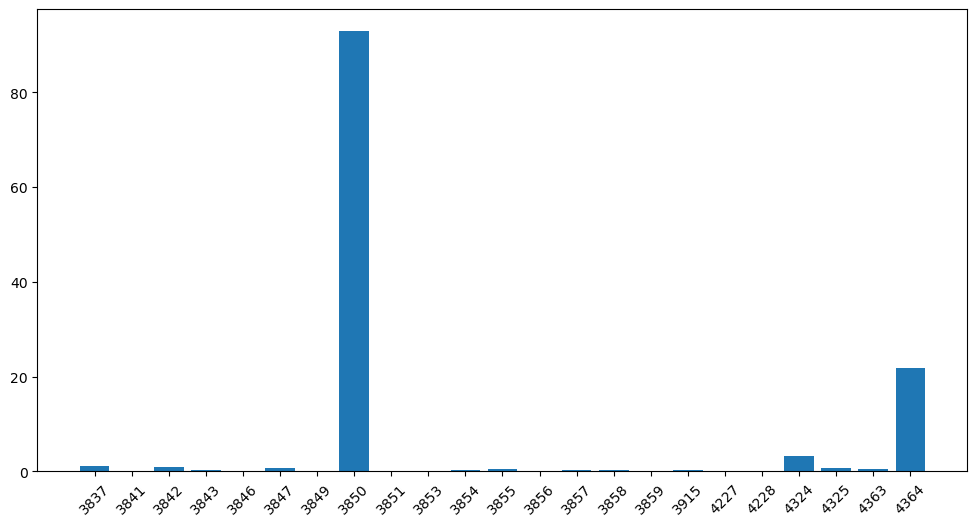

In [427]:
sites = []
nans = []
df_p_filt = df_p[df_p['time'] >= '2023-01-01']

for site, group in df_p_filt.groupby('site'):
    group = group.sort_values('time')
    group['time'] = pd.to_datetime(group['time'])
    sub = pd.merge(group, hour_range, on='time', how='right')

    nan_idxs = sub['pm25'].isnull()
    sub.loc[nan_idxs, 'pm25'] = -50
    
    nans.append((sub[nan_idxs].shape[0]/sub.shape[0])*100)
    sites.append(str(site))

plt.figure(figsize=(12,6))
plt.bar(sites, nans)
plt.xticks(rotation=45)
plt.show()

In [429]:
expected = pd.date_range(
    start=df_p_filt['time'].min(),
    end=df_p_filt['time'].max(),
    freq="1h"
)

for site, group in df_p_filt.groupby('site'):
    group = group[group['time'] >= '2023-01-01']
    missing = expected.difference(
        pd.DatetimeIndex(group['time'])
    )
    print(site)
    print("Количество пропусков:", len(missing))
    print()

3837
Количество пропусков: 143

3841
Количество пропусков: 0

3842
Количество пропусков: 108

3843
Количество пропусков: 0

3846
Количество пропусков: 0

3847
Количество пропусков: 61

3849
Количество пропусков: 0

3850
Количество пропусков: 24416

3851
Количество пропусков: 0

3853
Количество пропусков: 0

3854
Количество пропусков: 0

3855
Количество пропусков: 51

3856
Количество пропусков: 0

3857
Количество пропусков: 0

3858
Количество пропусков: 48

3859
Количество пропусков: 0

3915
Количество пропусков: 0

4227
Количество пропусков: 0

4228
Количество пропусков: 0

4324
Количество пропусков: 673

4325
Количество пропусков: 25

4363
Количество пропусков: 69

4364
Количество пропусков: 5707



In [485]:
pollution = pd.read_csv('../data/raw/pollution.csv')
meteo = pd.read_csv('../data/raw/meteo.csv')

In [487]:
# 0.
pollution['time'] = pd.to_datetime(pollution['time']).dt.tz_localize('Asia/Krasnoyarsk')
meteo['time'] = pd.to_datetime(meteo['time']).dt.tz_convert('Asia/Krasnoyarsk')

In [489]:
# 1.
pollution = pollution[pollution['time'] >= '2023-01-01']
meteo = meteo[meteo['time'] >= '2023-01-01']

In [491]:
# 2.

extended = []
time_df = pd.DataFrame({'time': pd.date_range(pollution['time'].min(), pollution['time'].max(),
                                              freq='1h')})
for site, group in pollution.groupby('site'):
    ext = pd.merge(group, time_df, on='time', how='right')
    ext['site'] = [site for _ in range(ext.shape[0])]
    extended.append(ext)
    
extended_pollution = pd.concat(extended).sort_values(['time','site']).reset_index(drop=True)

In [495]:
# 3.

sites_to_delete = [3850, 4324, 4364]
extended_pollution = extended_pollution[~extended_pollution['site'].isin(sites_to_delete)]

In [499]:
# 4.

interpolated = []

for site, group in extended_pollution.groupby('site'):
    intp = group.copy()
    intp = intp.sort_values('time')
    intp['pm25'] = intp['pm25'].interpolate('linear', limit_area='inside')
    interpolated.append(intp)

interpolated_pollution = pd.concat(interpolated).sort_values(['time','site']).reset_index(drop=True)

In [662]:
# 4.1

preprocessed_meteo_and_pollution = pd.merge(interpolated_pollution[['time','pm25']],
                                            meteo,
                                            on='time',
                                            how='inner')
preprocessed_meteo_and_pollution.to_csv('../data/preprocessed/preprocessed_meteo_and_pollution.csv',index=False)

In [527]:
# 5.
mean_pollution = interpolated_pollution.groupby('time')['pm25'].mean().reset_index().dropna()

In [567]:
# 6.

df_for_K = mean_pollution.copy()[['time','pm25']]
df_for_K['hour'] = df_for_K['time'].dt.hour
df_for_K['pm25_lag+1'] = df_for_K['pm25'].shift(-1)

emissions = df_for_K.groupby('hour')['pm25'].mean().reset_index()
emissions = emissions.rename(columns={'pm25': 'emission'})

df_for_K = pd.merge(df_for_K, emissions, on='hour').dropna()

In [569]:
df_for_K

,time,pm25,hour,pm25_lag+1,emission
0,2023-01-01 00:00:00+07:00,59.290,0,58.690,19.794690
1,2023-01-01 01:00:00+07:00,58.690,1,60.270,18.343043
2,2023-01-01 02:00:00+07:00,60.270,2,53.485,16.797510
3,2023-01-01 03:00:00+07:00,53.485,3,52.275,15.495837
4,2023-01-01 04:00:00+07:00,52.275,4,48.125,14.373581
...,...,...,...,...,...
26298,2025-12-31 18:00:00+07:00,8.310,18,7.795,16.856263
26299,2025-12-31 19:00:00+07:00,7.795,19,6.510,18.916579
26300,2025-12-31 20:00:00+07:00,6.510,20,7.970,20.211082
26301,2025-12-31 21:00:00+07:00,7.970,21,8.030,21.103395


In [571]:
# 7.

df_for_K['K'] = df_for_K['pm25_lag+1'] / (df_for_K['emission'] + df_for_K['pm25'])

In [663]:
# 8.

dataset = pd.merge(meteo, df_for_K[['time','K']], on='time', how='inner')

# 8.1
dataset.to_csv('../data/preprocessed/k_dataset.csv', index=False)

In [681]:
dataset.set_index('time').index.year

Index([2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023,
       ...
       2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025],
      dtype='int32', name='time', length=26303)

In [624]:
# 9.

train_dataset =  dataset[dataset['time'] < '2024-01-01']
val_dataset =  dataset[(dataset['time'] >= '2024-01-01') & (dataset['time'] < '2025-01-01')]
test_dataset =  dataset[dataset['time'] > '2025-01-01']

train_dataset.to_csv('../data/train/train.csv')
val_dataset.to_csv('../data/val/val.csv')
test_dataset.to_csv('../data/test/test.csv')

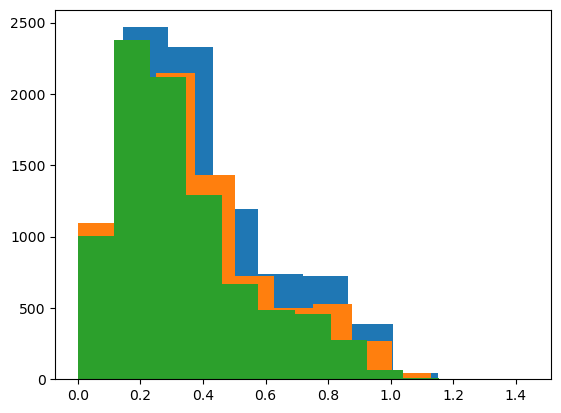

In [613]:
plt.hist(train_dataset['K'])
plt.hist(val_dataset['K'])
plt.hist(test_dataset['K'])
plt.show()